In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AG    = 40
N_IT    = 200
N_RUN   = 20
PEAK_R  = 0.12
N_TYPES = 12
BETA    = 0.08

np.random.seed(42)
print('설정 완료')

설정 완료


In [2]:
# ── 2D 멀티모달 함수 ──────────────────────────────────────────
def make_gaussian_mixture(peaks, sigma=0.07):
    peaks = np.array(peaks)
    def f(x):
        x2 = np.array(x)[:2]
        return -float(sum(np.exp(-np.sum((x2-p)**2)/(2*sigma**2)) for p in peaks))
    return f, peaks

def make_himmelblau():
    optima_orig = np.array([[3.0,2.0],[-2.805118,3.131312],
                            [-3.779310,-3.283186],[3.584428,-1.848126]])
    optima = (optima_orig + 5) / 10
    def f(x):
        z = np.array(x)[:2]*10-5
        return float((z[0]**2+z[1]-11)**2+(z[0]+z[1]**2-7)**2)
    return f, optima

PEAKS_4 = np.array([[0.2,0.2],[0.2,0.8],[0.8,0.2],[0.8,0.8]])
PEAKS_6 = np.array([[0.15,0.15],[0.15,0.85],[0.85,0.15],[0.85,0.85],[0.5,0.15],[0.5,0.85]])
PEAKS_9 = np.array([[i*0.35+0.15, j*0.35+0.15] for i in range(3) for j in range(3)])
GM4,OPT4  = make_gaussian_mixture(PEAKS_4, sigma=0.08)
GM6,OPT6  = make_gaussian_mixture(PEAKS_6, sigma=0.07)
GM9,OPT9  = make_gaussian_mixture(PEAKS_9, sigma=0.06)
HB,OPTHB  = make_himmelblau()
MULTIMODAL_2D = [(GM4,OPT4,'4-GM'),(GM6,OPT6,'6-GM'),(GM9,OPT9,'9-GM'),(HB,OPTHB,'Himmelblau')]

# ── 고차원 (D차원) 가우시안 혼합 ──────────────────────────────
def make_gaussian_mixture_nd(n_peaks, D, sigma=None, seed=0):
    rng = np.random.RandomState(seed)
    peaks = rng.rand(n_peaks, D)
    if sigma is None:
        sigma = 0.3 / np.sqrt(D)   # D 커질수록 봉우리 넓어야 닿음
    def f(x):
        xd = np.array(x)[:D]
        return -float(sum(np.exp(-np.sum((xd-p)**2)/(2*sigma**2)) for p in peaks))
    return f, peaks

GM_5D,  OPT_5D  = make_gaussian_mixture_nd(8,  D=5,  seed=1)
GM_10D, OPT_10D = make_gaussian_mixture_nd(8,  D=10, seed=2)

# ── 동적 환경 (이동하는 봉우리) ───────────────────────────────
def make_dynamic_gm(n_peaks=6, speed=0.004, sigma=0.07, seed=0):
    rng = np.random.RandomState(seed)
    centers = rng.rand(n_peaks, 2)
    vels    = (rng.rand(n_peaks, 2) - 0.5) * speed * 2

    def get_optima(t):
        c = centers.copy()
        c = c + vels * t
        # 벽 반사
        c = np.where(c < 0, -c, c)
        c = np.where(c > 1, 2-c, c)
        return np.clip(c, 0.01, 0.99)

    def f_at_t(x, t):
        c = get_optima(t)
        x2 = np.array(x)[:2]
        return -float(sum(np.exp(-np.sum((x2-p)**2)/(2*sigma**2)) for p in c))

    return f_at_t, get_optima, n_peaks

DYN_F, DYN_OPTIMA, DYN_N_PEAKS = make_dynamic_gm(n_peaks=6, speed=0.004)

# ── 메트릭 ────────────────────────────────────────────────────
def peak_ratio(positions, optima, radius=PEAK_R):
    found = set()
    for pos in positions:
        for k, opt in enumerate(optima):
            if np.linalg.norm(np.array(pos)-np.array(opt)) < radius:
                found.add(k)
    return len(found) / len(optima)

def diversity(positions):
    pos = np.array(positions); n = len(pos)
    d = [np.linalg.norm(pos[i]-pos[j]) for i in range(n) for j in range(i+1,n)]
    return float(np.mean(d)) if d else 0.

print('함수 준비 완료  (2D / 고차원 / 동적)')

함수 준비 완료  (2D / 고차원 / 동적)


In [3]:
# ── Advanced AISO 변형 ─────────────────────────────────────────
# 기본 AISO (튜닝 최적값 고정: m_low=-0.5, w_repel=2.0)
def run_aiso_base(f, optima, seed, D=2, k=3, alpha=0.2, m_low=-0.5, w_repel=2.0):
    np.random.seed(seed)
    M = np.random.uniform(m_low, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f(X[i]) for i in range(N_AG)])
    for _ in range(N_IT):
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1); ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return X, S, peak_ratio(X, optima), diversity(X)


# ── Adaptive AISO: diversity 기반 w_repel 자동 조절 ──────────
def run_aiso_adaptive(f, optima, seed, D=2, k=3, alpha=0.2, m_low=-0.5):
    np.random.seed(seed)
    M = np.random.uniform(m_low, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f(X[i]) for i in range(N_AG)])
    for _ in range(N_IT):
        # diversity 낮으면 척력 강화 (범위: 1.0 ~ 4.0)
        div = diversity(X)
        w_repel = 1.0 + 3.0 * np.exp(-div / 0.12)
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1); ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return X, S, peak_ratio(X, optima), diversity(X)


# ── Archive AISO: 발견한 봉우리 저장 + 주변 에이전트 재시작 ──
def run_aiso_archive(f, optima, seed, D=2, k=3, alpha=0.2, m_low=-0.5, w_repel=2.0,
                     archive_r=0.10, restart_every=25):
    np.random.seed(seed)
    M = np.random.uniform(m_low, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f(X[i]) for i in range(N_AG)])
    archive = []
    for it in range(N_IT):
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1); ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                # 새 봉우리: 기존 아카이브에서 멀면 저장
                if all(np.linalg.norm(X[i]-a) > archive_r for a in archive):
                    archive.append(X[i].copy())
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
        # 아카이브 봉우리 근처 에이전트 재시작 (탐색 유지)
        if archive and it % restart_every == 0:
            for i in range(N_AG):
                if any(np.linalg.norm(X[i]-a) < archive_r*0.4 for a in archive):
                    X[i] = np.random.rand(D); S[i] = f(X[i])
    # 최종 PR: 현재 위치 + 아카이브 위치 합산
    all_pos = list(X) + archive
    return X, S, peak_ratio(all_pos, optima), diversity(X)


# ── Full AISO: Adaptive + Archive 결합 ───────────────────────
def run_aiso_full(f, optima, seed, D=2, k=3, alpha=0.2, m_low=-0.5,
                  archive_r=0.10, restart_every=25):
    np.random.seed(seed)
    M = np.random.uniform(m_low, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f(X[i]) for i in range(N_AG)])
    archive = []
    for it in range(N_IT):
        div = diversity(X)
        w_repel = 1.0 + 3.0 * np.exp(-div / 0.12)
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1); ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                if all(np.linalg.norm(X[i]-a) > archive_r for a in archive):
                    archive.append(X[i].copy())
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
        if archive and it % restart_every == 0:
            for i in range(N_AG):
                if any(np.linalg.norm(X[i]-a) < archive_r*0.4 for a in archive):
                    X[i] = np.random.rand(D); S[i] = f(X[i])
    all_pos = list(X) + archive
    return X, S, peak_ratio(all_pos, optima), diversity(X)


print('Advanced AISO 정의 완료: base / adaptive / archive / full')

Advanced AISO 정의 완료: base / adaptive / archive / full


In [4]:
# ── SOTA 알고리즘 (D차원 지원) ────────────────────────────────
def run_spso(f, optima, seed, D=2, r_species=0.2):
    np.random.seed(seed); w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG,D); V=np.zeros((N_AG,D))
    S=np.array([f(X[i]) for i in range(N_AG)])
    pX=X.copy(); pS=S.copy()
    for _ in range(N_IT):
        order=np.argsort(pS); assigned=np.zeros(N_AG,dtype=bool); seed_map=np.zeros(N_AG,dtype=int)
        for i in order:
            if not assigned[i]:
                for j in range(N_AG):
                    if np.linalg.norm(pX[i]-pX[j])<r_species:
                        assigned[j]=True; seed_map[j]=i
        for i in range(N_AG):
            r1,r2=np.random.rand(D),np.random.rand(D)
            V[i]=w*V[i]+c1*r1*(pX[i]-X[i])+c2*r2*(pX[seed_map[i]]-X[i])
            X[i]=np.clip(X[i]+V[i],0,1)
        S=np.array([f(X[i]) for i in range(N_AG)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
    return X, S, peak_ratio(X, optima), diversity(X)

def run_crowding_de(f, optima, seed, D=2, F=0.5, CR=0.9):
    np.random.seed(seed)
    X=np.random.rand(N_AG,D); S=np.array([f(X[i]) for i in range(N_AG)])
    for _ in range(N_IT):
        for i in range(N_AG):
            pool=[j for j in range(N_AG) if j!=i]
            r1,r2,r3=np.random.choice(pool,3,replace=False)
            mutant=np.clip(X[r1]+F*(X[r2]-X[r3]),0,1)
            mask=np.random.rand(D)<CR; trial=np.where(mask,mutant,X[i])
            dists=np.array([np.linalg.norm(X[j]-trial) for j in range(N_AG)])
            dists[i]=np.inf; crowd=np.argmin(dists); ns=f(trial)
            if ns<S[crowd]: X[crowd]=trial; S[crowd]=ns
    return X, S, peak_ratio(X, optima), diversity(X)

print('SOTA 정의 완료: SPSO / Crowding-DE (D차원 지원)')

SOTA 정의 완료: SPSO / Crowding-DE (D차원 지원)


## Part 1 — 2D 벤치마크: Advanced AISO vs SOTA

AISO(base) / AISO(adaptive) / AISO(archive) / AISO(full) vs SPSO / Crowding-DE

In [5]:
ALGOS_2D = {
    'AISO(base)'    : lambda f,o,seed: run_aiso_base(f,o,seed,D=2),
    'AISO(adaptive)': lambda f,o,seed: run_aiso_adaptive(f,o,seed,D=2),
    'AISO(archive)' : lambda f,o,seed: run_aiso_archive(f,o,seed,D=2),
    'AISO(full)'    : lambda f,o,seed: run_aiso_full(f,o,seed,D=2),
    'SPSO'          : lambda f,o,seed: run_spso(f,o,seed,D=2),
    'Crowding-DE'   : lambda f,o,seed: run_crowding_de(f,o,seed,D=2),
}

res2d = {}
for aname, afn in ALGOS_2D.items():
    print(f'\n── {aname} ──')
    res2d[aname] = {}
    for fn, opts, fname in MULTIMODAL_2D:
        pr_list, rt_list = [], []
        for r in range(N_RUN):
            t0 = time.perf_counter()
            _, _, pr, _ = afn(fn, opts, seed=42+r)
            rt_list.append(time.perf_counter()-t0)
            pr_list.append(pr)
        res2d[aname][fname] = {'pr': pr_list, 'rt': rt_list}
        print(f'  {fname:<12} PR={np.mean(pr_list):.3f}  rt={np.mean(rt_list):.2f}s')
print('\n✓ 완료!')


── AISO(base) ──
  4-GM         PR=0.988  rt=1.88s
  6-GM         PR=0.925  rt=2.57s
  9-GM         PR=0.928  rt=2.67s
  Himmelblau   PR=0.938  rt=1.00s

── AISO(adaptive) ──
  4-GM         PR=0.975  rt=2.37s
  6-GM         PR=0.917  rt=3.88s
  9-GM         PR=0.922  rt=4.31s
  Himmelblau   PR=0.950  rt=2.35s

── AISO(archive) ──
  4-GM         PR=1.000  rt=2.88s
  6-GM         PR=0.983  rt=3.20s
  9-GM         PR=0.978  rt=3.32s
  Himmelblau   PR=0.950  rt=0.77s

── AISO(full) ──
  4-GM         PR=1.000  rt=2.11s
  6-GM         PR=0.967  rt=2.27s
  9-GM         PR=0.978  rt=2.61s
  Himmelblau   PR=0.963  rt=1.75s

── SPSO ──
  4-GM         PR=1.000  rt=1.07s
  6-GM         PR=0.992  rt=1.14s
  9-GM         PR=0.956  rt=4.21s
  Himmelblau   PR=1.000  rt=1.57s

── Crowding-DE ──
  4-GM         PR=1.000  rt=3.70s
  6-GM         PR=1.000  rt=3.31s
  9-GM         PR=1.000  rt=3.55s
  Himmelblau   PR=1.000  rt=5.13s

✓ 완료!


=== 2D 순위 ===
  1위  Crowding-DE     : PR=1.0000  RT=3.92s
  2위  SPSO            : PR=0.9868  RT=2.00s
  3위  AISO(archive)   : PR=0.9778  RT=2.54s ★
  4위  AISO(full)      : PR=0.9767  RT=2.19s ★
  5위  AISO(base)      : PR=0.9444  RT=2.03s ★
  6위  AISO(adaptive)  : PR=0.9410  RT=3.23s ★


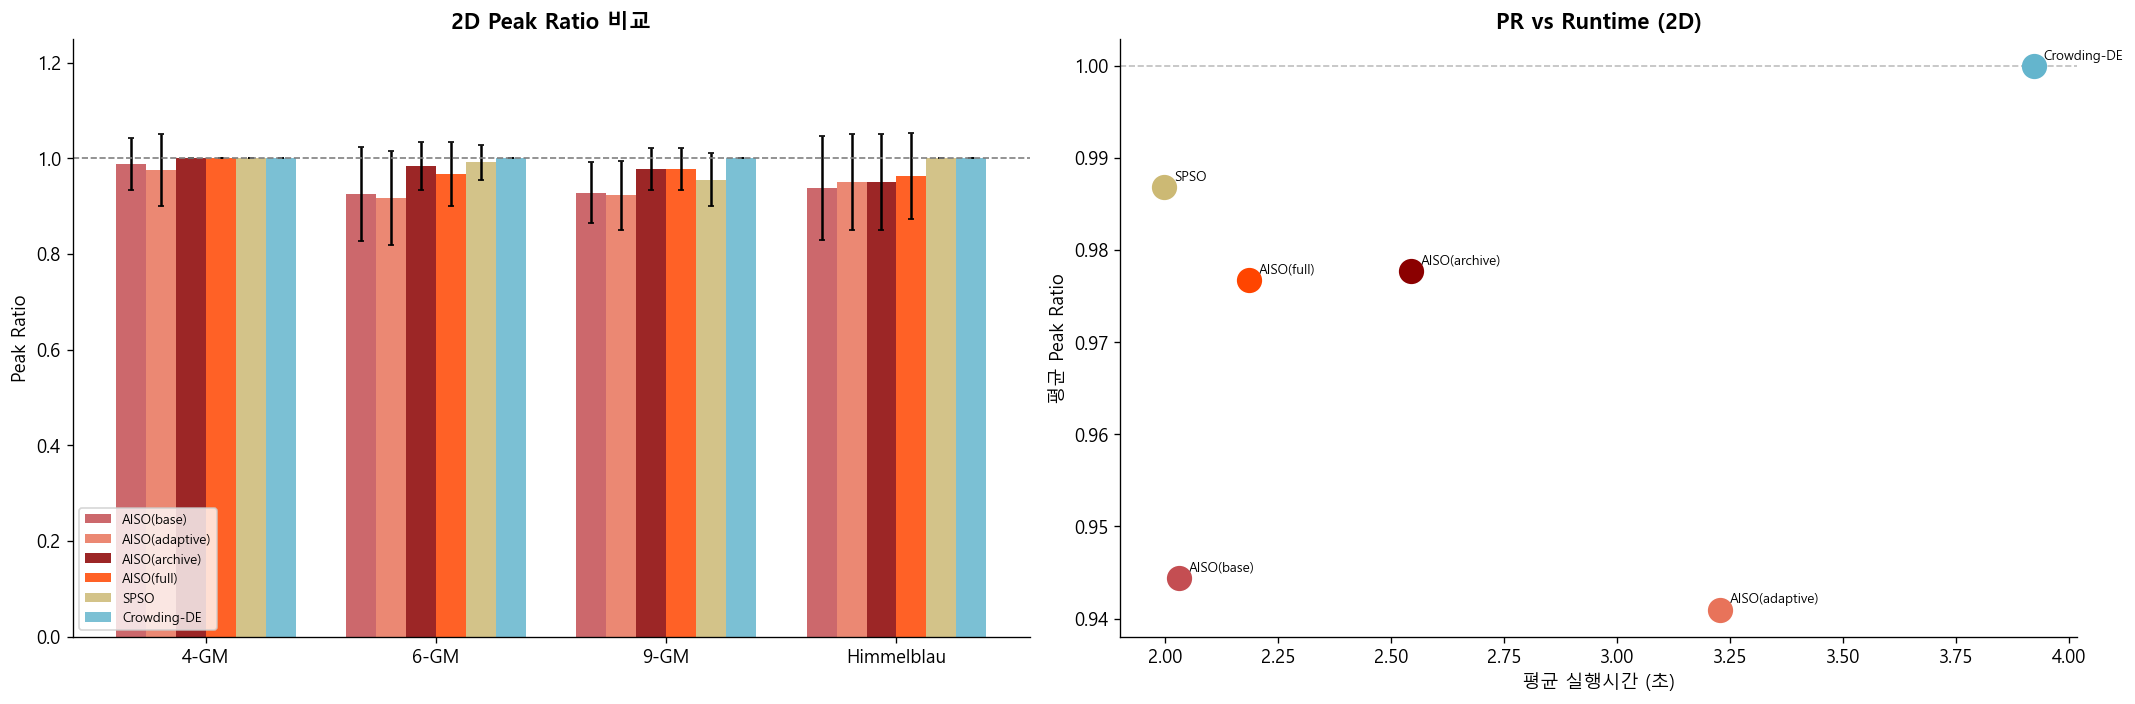

In [6]:
COLORS_2D = {
    'AISO(base)'    :'#C44E52', 'AISO(adaptive)':'#E8735A',
    'AISO(archive)' :'#8B0000', 'AISO(full)'    :'#FF4500',
    'SPSO'          :'#CCB974', 'Crowding-DE'   :'#64B5CD',
}
fn_names_2d = [n for _,_,n in MULTIMODAL_2D]
algo_order_2d = list(ALGOS_2D.keys())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(fn_names_2d)); width = 0.13

# PR 바차트
ax = axes[0]
for k, aname in enumerate(algo_order_2d):
    pr_m = [np.mean(res2d[aname][fn]['pr']) for fn in fn_names_2d]
    pr_s = [np.std(res2d[aname][fn]['pr'])  for fn in fn_names_2d]
    ax.bar(x+k*width, pr_m, width, label=aname, color=COLORS_2D[aname],
           yerr=pr_s, capsize=2, alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xticks(x+2.5*width); ax.set_xticklabels(fn_names_2d)
ax.set_ylabel('Peak Ratio'); ax.set_ylim(0, 1.25)
ax.set_title('2D Peak Ratio 비교', fontweight='bold'); ax.legend(fontsize=8)

# PR vs RT 산점도
ax = axes[1]
for aname in algo_order_2d:
    avg_pr = np.mean([np.mean(res2d[aname][fn]['pr']) for fn in fn_names_2d])
    avg_rt = np.mean([np.mean(res2d[aname][fn]['rt']) for fn in fn_names_2d])
    ax.scatter(avg_rt, avg_pr, s=200, color=COLORS_2D[aname], zorder=5, label=aname)
    ax.annotate(aname, (avg_rt, avg_pr), xytext=(6,4), textcoords='offset points', fontsize=8)
ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('평균 실행시간 (초)'); ax.set_ylabel('평균 Peak Ratio')
ax.set_title('PR vs Runtime (2D)', fontweight='bold')

# 순위 출력
print('=== 2D 순위 ===')
ranking = sorted(algo_order_2d,
    key=lambda a: np.mean([np.mean(res2d[a][fn]['pr']) for fn in fn_names_2d]), reverse=True)
for i, a in enumerate(ranking, 1):
    avg = np.mean([np.mean(res2d[a][fn]['pr']) for fn in fn_names_2d])
    rt  = np.mean([np.mean(res2d[a][fn]['rt']) for fn in fn_names_2d])
    tag = ' ★' if 'AISO' in a else ''
    print(f'  {i}위  {a:<16}: PR={avg:.4f}  RT={rt:.2f}s{tag}')

plt.tight_layout()
plt.savefig('aiso_advanced_2d.png', bbox_inches='tight')
plt.show()

## Part 2 — 고차원 (5D / 10D)

차원 증가 시 AISO vs SPSO vs Crowding-DE 비교  
봉우리 8개, D=5 / D=10, PEAK_R은 D에 맞게 조정


── AISO(full) ──
  4-GM (2D)     : PR=0.975
  8-GM (5D)     : PR=0.263
  8-GM (10D)    : PR=0.019

── SPSO ──
  4-GM (2D)     : PR=1.000
  8-GM (5D)     : PR=0.125
  8-GM (10D)    : PR=0.000

── Crowding-DE ──
  4-GM (2D)     : PR=1.000
  8-GM (5D)     : PR=1.000
  8-GM (10D)    : PR=0.938

✓ 완료!


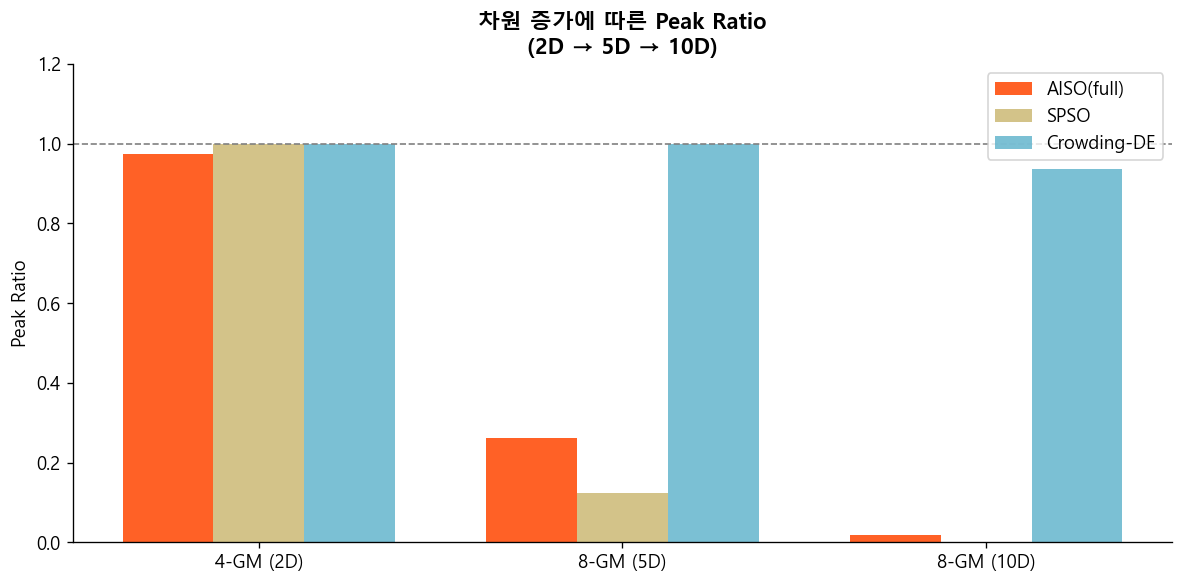

In [7]:
ND_CASES = [
    (GM4,   OPT4,   '4-GM (2D)', 2,  0.12),
    (GM_5D, OPT_5D, '8-GM (5D)', 5,  0.25),
    (GM_10D,OPT_10D,'8-GM (10D)',10, 0.40),
]

ALGOS_ND = {
    'AISO(full)'  : run_aiso_full,
    'SPSO'        : run_spso,
    'Crowding-DE' : run_crowding_de,
}

res_nd = {}
for aname, afn in ALGOS_ND.items():
    print(f'\n── {aname} ──')
    res_nd[aname] = {}
    for fn, opts, fname, D, pr_r in ND_CASES:
        pr_list = []
        for r in range(N_RUN):
            X, S, _, _ = afn(fn, opts, seed=42+r, D=D)
            pr = peak_ratio(X, opts, radius=pr_r)
            pr_list.append(pr)
        res_nd[aname][fname] = np.mean(pr_list)
        print(f'  {fname:<14}: PR={np.mean(pr_list):.3f}')

print('\n✓ 완료!')

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
fn_nd = [f for _,_,f,_,_ in ND_CASES]
x = np.arange(len(fn_nd)); width = 0.25
colors_nd = {'AISO(full)':'#FF4500','SPSO':'#CCB974','Crowding-DE':'#64B5CD'}
for k, aname in enumerate(ALGOS_ND):
    vals = [res_nd[aname][fn] for fn in fn_nd]
    ax.bar(x+k*width, vals, width, label=aname, color=colors_nd[aname], alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xticks(x+width); ax.set_xticklabels(fn_nd)
ax.set_ylabel('Peak Ratio'); ax.set_ylim(0, 1.2)
ax.set_title('차원 증가에 따른 Peak Ratio\n(2D → 5D → 10D)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('aiso_advanced_nd.png', bbox_inches='tight')
plt.show()

## Part 3 — 동적 환경 (이동하는 봉우리)

봉우리가 매 T_CHANGE=20 이터레이션마다 이동  
AISO의 타입 다양성 → 수렴 없이 공간 유지 → 추적 유리 가설

In [8]:
T_CHANGE = 20   # 이 간격마다 봉우리 이동 + PR 측정

def run_dynamic(algo_fn, seed, D=2, use_adaptive=False):
    """동적 환경 실행: PR 시계열 반환"""
    np.random.seed(seed)
    M = np.random.uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    current_t = 0
    S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
    pr_history = []

    for it in range(N_IT):
        if it > 0 and it % T_CHANGE == 0:
            current_t = it
            S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
            opt_now = DYN_OPTIMA(current_t)
            pr_history.append(peak_ratio(X, opt_now))

        div = diversity(X)
        w_repel = (1.0 + 3.0 * np.exp(-div / 0.12)) if use_adaptive else 2.0
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        k = 3; alpha = 0.2
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1)
            ns = DYN_F(nX, current_t)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return pr_history

def run_spso_dynamic(seed, D=2, r_species=0.2):
    np.random.seed(seed); w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG,D); V=np.zeros((N_AG,D))
    current_t = 0
    S=np.array([DYN_F(X[i],current_t) for i in range(N_AG)])
    pX=X.copy(); pS=S.copy(); pr_history=[]
    for it in range(N_IT):
        if it>0 and it%T_CHANGE==0:
            current_t=it; S=np.array([DYN_F(X[i],current_t) for i in range(N_AG)])
            pS=np.minimum(pS,S); pr_history.append(peak_ratio(X,DYN_OPTIMA(current_t)))
        order=np.argsort(pS); assigned=np.zeros(N_AG,dtype=bool); seed_map=np.zeros(N_AG,dtype=int)
        for i in order:
            if not assigned[i]:
                for j in range(N_AG):
                    if np.linalg.norm(pX[i]-pX[j])<r_species:
                        assigned[j]=True; seed_map[j]=i
        for i in range(N_AG):
            r1,r2=np.random.rand(D),np.random.rand(D)
            V[i]=w*V[i]+c1*r1*(pX[i]-X[i])+c2*r2*(pX[seed_map[i]]-X[i])
            X[i]=np.clip(X[i]+V[i],0,1)
        S2=np.array([DYN_F(X[i],current_t) for i in range(N_AG)])
        bt=S2<pS; pX[bt]=X[bt]; pS[bt]=S2[bt]
    return pr_history

def run_cde_dynamic(seed, D=2, F=0.5, CR=0.9):
    np.random.seed(seed); current_t=0
    X=np.random.rand(N_AG,D); S=np.array([DYN_F(X[i],current_t) for i in range(N_AG)])
    pr_history=[]
    for it in range(N_IT):
        if it>0 and it%T_CHANGE==0:
            current_t=it; S=np.array([DYN_F(X[i],current_t) for i in range(N_AG)])
            pr_history.append(peak_ratio(X,DYN_OPTIMA(current_t)))
        for i in range(N_AG):
            pool=[j for j in range(N_AG) if j!=i]
            r1,r2,r3=np.random.choice(pool,3,replace=False)
            mutant=np.clip(X[r1]+F*(X[r2]-X[r3]),0,1)
            mask=np.random.rand(D)<CR; trial=np.where(mask,mutant,X[i])
            ns=DYN_F(trial,current_t)
            dists=np.array([np.linalg.norm(X[j]-trial) for j in range(N_AG)])
            dists[i]=np.inf; crowd=np.argmin(dists)
            if ns<S[crowd]: X[crowd]=trial; S[crowd]=ns
    return pr_history

# ── 실행 (N_RUN 평균) ─────────────────────────────────────────
print('동적 환경 실험 시작...')
dyn_algos = {
    'AISO(base)'    : lambda s: run_dynamic(None, s, use_adaptive=False),
    'AISO(adaptive)': lambda s: run_dynamic(None, s, use_adaptive=True),
    'SPSO'          : run_spso_dynamic,
    'Crowding-DE'   : run_cde_dynamic,
}
dyn_results = {}
for aname, afn in dyn_algos.items():
    histories = [afn(42+r) for r in range(N_RUN)]
    # 시계열 평균
    min_len = min(len(h) for h in histories)
    arr = np.array([h[:min_len] for h in histories])
    dyn_results[aname] = {'mean': arr.mean(0), 'std': arr.std(0)}
    print(f'  {aname:<16}: avg tracking PR={arr.mean():.3f}')
print('\n✓ 완료!')

동적 환경 실험 시작...
  AISO(base)      : avg tracking PR=0.206
  AISO(adaptive)  : avg tracking PR=0.219
  SPSO            : avg tracking PR=0.631
  Crowding-DE     : avg tracking PR=0.989

✓ 완료!


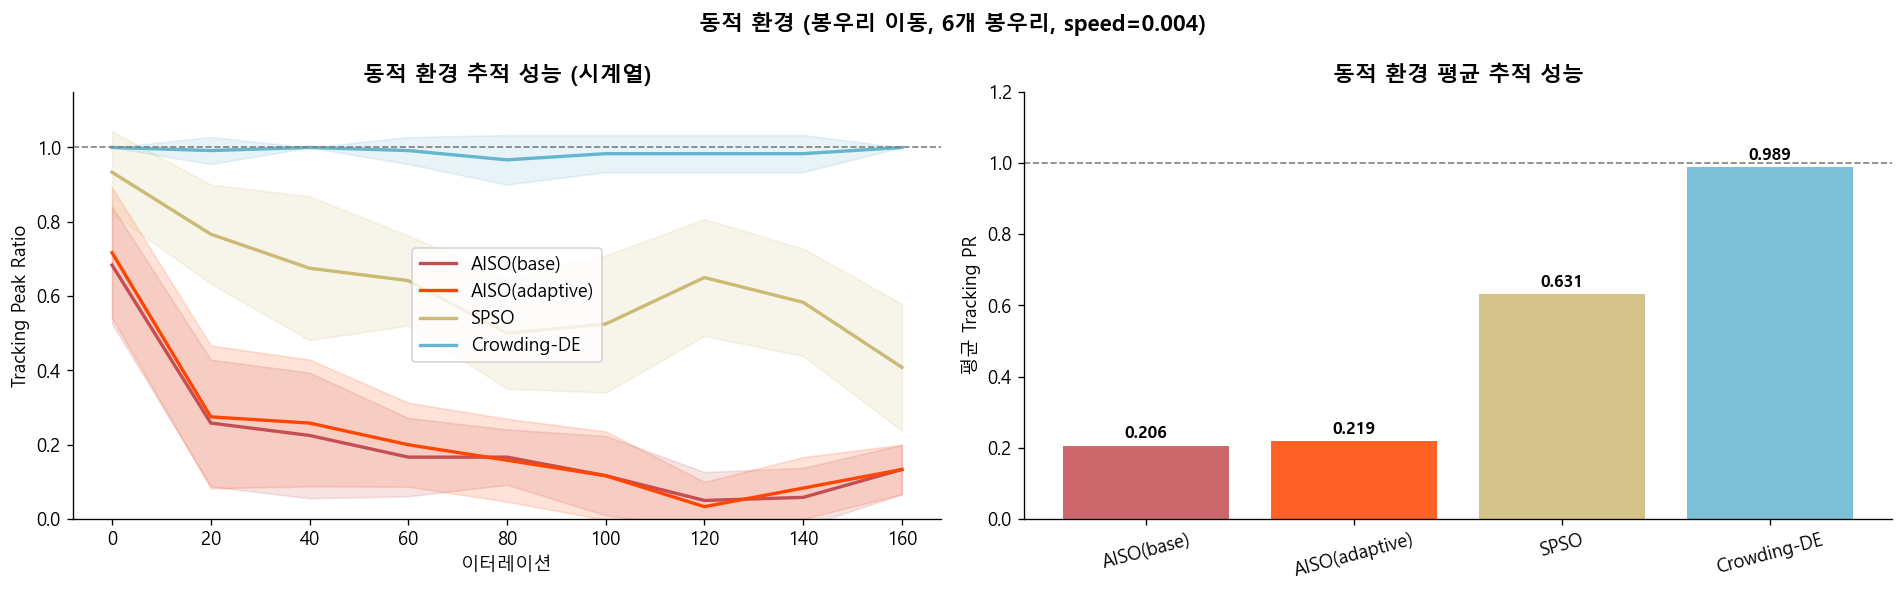

=== 동적 환경 순위 ===
  1위  Crowding-DE     : avg tracking PR=0.9889
  2위  SPSO            : avg tracking PR=0.6315
  3위  AISO(adaptive)  : avg tracking PR=0.2194 ★
  4위  AISO(base)      : avg tracking PR=0.2065 ★


In [9]:
COLORS_DYN = {
    'AISO(base)'    :'#C44E52', 'AISO(adaptive)':'#FF4500',
    'SPSO'          :'#CCB974', 'Crowding-DE'   :'#64B5CD',
}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 시계열 라인 차트
ax = axes[0]
for aname, data in dyn_results.items():
    t = np.arange(len(data['mean'])) * T_CHANGE
    ax.plot(t, data['mean'], color=COLORS_DYN[aname], label=aname, lw=2)
    ax.fill_between(t, data['mean']-data['std'], data['mean']+data['std'],
                    color=COLORS_DYN[aname], alpha=0.15)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('이터레이션'); ax.set_ylabel('Tracking Peak Ratio')
ax.set_title('동적 환경 추적 성능 (시계열)', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.15)

# 평균 tracking PR 바차트
ax = axes[1]
avg_tracking = {a: dyn_results[a]['mean'].mean() for a in dyn_algos}
names = list(avg_tracking.keys())
vals  = [avg_tracking[n] for n in names]
bars = ax.bar(names, vals, color=[COLORS_DYN[n] for n in names], alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylabel('평균 Tracking PR'); ax.set_ylim(0, 1.2)
ax.set_title('동적 환경 평균 추적 성능', fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('동적 환경 (봉우리 이동, 6개 봉우리, speed=0.004)', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_advanced_dynamic.png', bbox_inches='tight')
plt.show()

print('=== 동적 환경 순위 ===')
for i, (a, v) in enumerate(sorted(avg_tracking.items(), key=lambda x:-x[1]), 1):
    tag = ' ★' if 'AISO' in a else ''
    print(f'  {i}위  {a:<16}: avg tracking PR={v:.4f}{tag}')

## Part 4 — 동적 환경 개선: W 다양성 유지

**문제**: W 업데이트가 타입을 수렴시켜 시간이 지날수록 다양성이 죽음  
**시도**:
- `W-frozen`: W 업데이트 완전 동결 → 타입 다양성 고정 유지
- `W-reset`: 매 T_CHANGE마다 일부 에이전트 W 랜덤 리셋 → 봉우리 이동 감지 후 재탐색
- `M-adaptive`: M 행렬을 성능 기반으로 강화 (좋은 타입 조합 학습)

In [10]:
def run_dynamic_v2(seed, use_adaptive=False, freeze_w=False,
                   reset_w=False, reset_ratio=0.3,
                   adaptive_m=False, D=2):
    np.random.seed(seed)
    M = np.random.uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, D)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    W_init = W.copy()   # 초기 W 저장 (reset용)
    current_t = 0
    S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
    pr_history = []; w_repel = 2.0
    prev_S_mean = S.mean()

    for it in range(N_IT):
        if it > 0 and it % T_CHANGE == 0:
            current_t = it
            S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
            opt_now = DYN_OPTIMA(current_t)
            pr_history.append(peak_ratio(X, opt_now))

            # W-reset: 봉우리 이동 시 일부 에이전트 W 리셋
            if reset_w:
                n_reset = int(N_AG * reset_ratio)
                idx = np.random.choice(N_AG, n_reset, replace=False)
                W[idx] = np.random.dirichlet(np.ones(N_TYPES), n_reset)

            # M-adaptive: 성능 하락 시 M 갱신
            if adaptive_m:
                cur_mean = S.mean()
                if cur_mean > prev_S_mean * 0.95:  # 성능 하락
                    M = np.random.uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
                prev_S_mean = cur_mean

        if use_adaptive:
            div = diversity(X)
            w_repel = 1.0 + 3.0 * np.exp(-div / 0.12)

        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        k = 3; alpha = 0.2
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1)
            ns = DYN_F(nX, current_t)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                if not freeze_w:   # W 동결 여부
                    bja = top_a[np.argmax(ci[top_a])]
                    W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return pr_history


print('동적 환경 개선 버전 정의 완료')
print('실험 시작...')

dyn_v2_algos = {
    'AISO(base)'      : lambda s: run_dynamic_v2(s),
    'AISO(W-frozen)'  : lambda s: run_dynamic_v2(s, freeze_w=True),
    'AISO(W-reset)'   : lambda s: run_dynamic_v2(s, reset_w=True, reset_ratio=0.3),
    'AISO(W-reset50)' : lambda s: run_dynamic_v2(s, reset_w=True, reset_ratio=0.5),
    'AISO(M-adaptive)': lambda s: run_dynamic_v2(s, adaptive_m=True),
    'AISO(all)'       : lambda s: run_dynamic_v2(s, freeze_w=False, reset_w=True,
                                                  reset_ratio=0.3, adaptive_m=True,
                                                  use_adaptive=True),
}

dyn_v2_results = {}
for aname, afn in dyn_v2_algos.items():
    histories = [afn(42+r) for r in range(N_RUN)]
    min_len = min(len(h) for h in histories)
    arr = np.array([h[:min_len] for h in histories])
    dyn_v2_results[aname] = {'mean': arr.mean(0), 'std': arr.std(0)}
    print(f'  {aname:<20}: avg PR={arr.mean():.3f}')

print('\n✓ 완료!')

동적 환경 개선 버전 정의 완료
실험 시작...
  AISO(base)          : avg PR=0.206
  AISO(W-frozen)      : avg PR=0.232
  AISO(W-reset)       : avg PR=0.201
  AISO(W-reset50)     : avg PR=0.194
  AISO(M-adaptive)    : avg PR=0.197
  AISO(all)           : avg PR=0.217

✓ 완료!


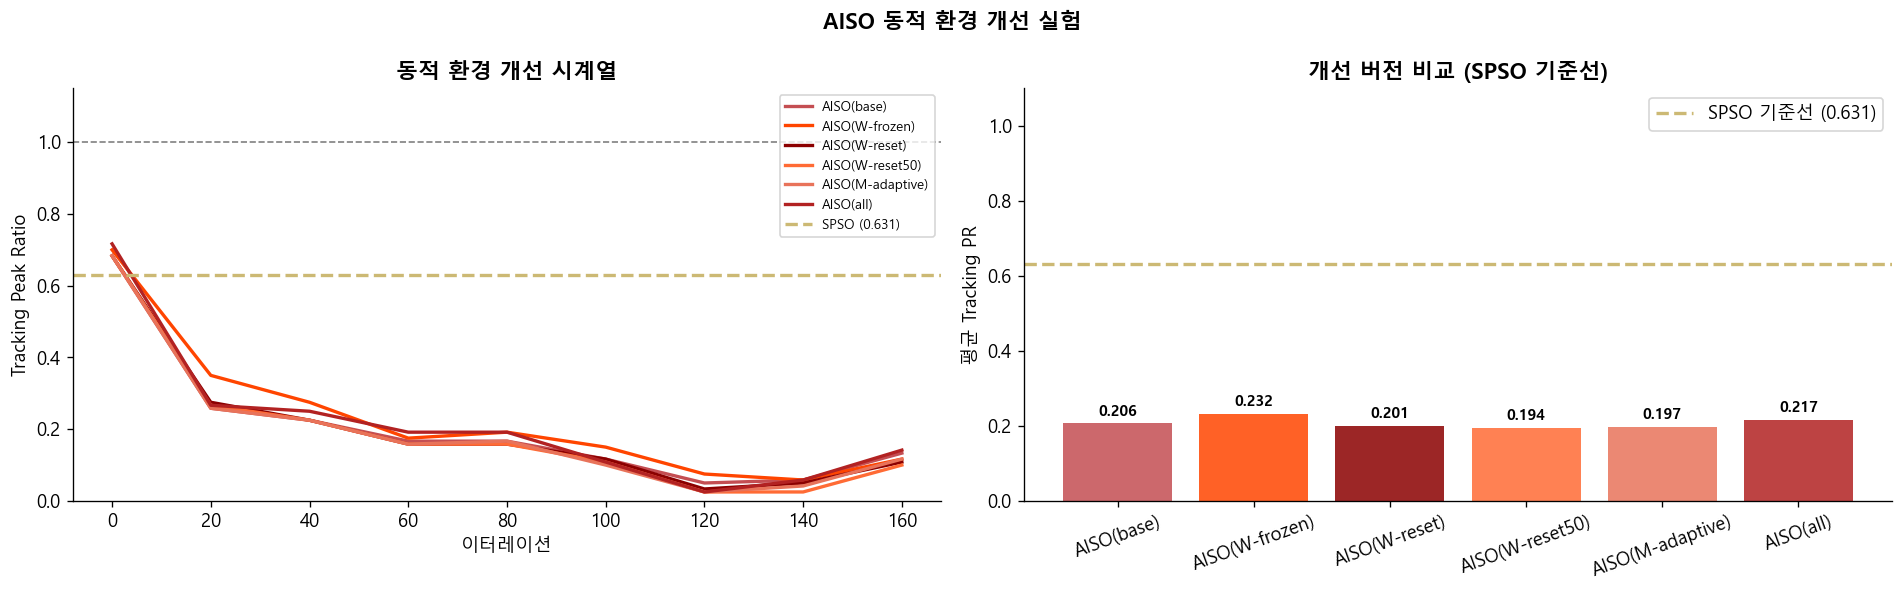


=== 동적 개선 순위 ===
  1위  AISO(W-frozen)      : 0.2324  (+0.026 vs base)
  2위  AISO(all)           : 0.2167  (+0.011 vs base)
  3위  AISO(base)          : 0.2065  (+0.000 vs base)
  4위  AISO(W-reset)       : 0.2009  (+-0.005 vs base)
  5위  AISO(M-adaptive)    : 0.1972  (+-0.009 vs base)
  6위  AISO(W-reset50)     : 0.1944  (+-0.012 vs base)


In [11]:
COLORS_V2 = {
    'AISO(base)'      :'#C44E52', 'AISO(W-frozen)'  :'#FF4500',
    'AISO(W-reset)'   :'#8B0000', 'AISO(W-reset50)' :'#FF6B35',
    'AISO(M-adaptive)':'#E8735A', 'AISO(all)'       :'#B22222',
}
SPSO_AVG = 0.631   # Part 3 결과 참조

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for aname, data in dyn_v2_results.items():
    t = np.arange(len(data['mean'])) * T_CHANGE
    ax.plot(t, data['mean'], color=COLORS_V2[aname], label=aname, lw=2)
ax.axhline(SPSO_AVG, color='#CCB974', ls='--', lw=2, label=f'SPSO ({SPSO_AVG})')
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('이터레이션'); ax.set_ylabel('Tracking Peak Ratio')
ax.set_title('동적 환경 개선 시계열', fontweight='bold')
ax.legend(fontsize=8); ax.set_ylim(0, 1.15)

ax = axes[1]
avgs = {a: dyn_v2_results[a]['mean'].mean() for a in dyn_v2_algos}
names = list(avgs.keys()); vals = [avgs[n] for n in names]
bars = ax.bar(names, vals, color=[COLORS_V2[n] for n in names], alpha=0.85)
ax.axhline(SPSO_AVG, color='#CCB974', ls='--', lw=2, label=f'SPSO 기준선 ({SPSO_AVG})')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('평균 Tracking PR'); ax.set_ylim(0, 1.1)
ax.set_title('개선 버전 비교 (SPSO 기준선)', fontweight='bold')
ax.legend(); ax.tick_params(axis='x', rotation=20)

plt.suptitle('AISO 동적 환경 개선 실험', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_advanced_dynamic_v2.png', bbox_inches='tight')
plt.show()

print('\n=== 동적 개선 순위 ===')
for i, (a, v) in enumerate(sorted(avgs.items(), key=lambda x:-x[1]), 1):
    diff = v - 0.206
    print(f'  {i}위  {a:<20}: {v:.4f}  (+{diff:.3f} vs base)')